In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/cleaned_retail_data.csv")

df.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_14244\828282448.py:6: DtypeWarning: Columns (0: Invoice) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/cleaned_retail_data.csv")


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [4]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Sales'],
      dtype='str')

In [5]:
clv = df.groupby("Customer ID").agg({
    "Sales":"sum",
    "Invoice":"nunique"
})

clv.columns = ["Total_Revenue","Total_Orders"]

clv["CLV"] = clv["Total_Revenue"]

clv.head()

,Total_Revenue,Total_Orders,CLV
Customer ID,,,
12346.0,77556.46,12,77556.46
12347.0,5633.32,8,5633.32
12348.0,2019.40,5,2019.40
12349.0,4428.69,4,4428.69
12350.0,334.40,1,334.40


In [6]:
clv.sort_values(
    "CLV",
    ascending=False
).head(10)

,Total_Revenue,Total_Orders,CLV
Customer ID,,,
18102.0,608821.65,145,608821.65
14646.0,528602.52,151,528602.52
14156.0,313946.37,156,313946.37
14911.0,295972.63,398,295972.63
17450.0,246973.09,52,246973.09
13694.0,196482.81,143,196482.81
17511.0,175603.55,60,175603.55
16446.0,168472.50,2,168472.50
16684.0,147142.77,55,147142.77


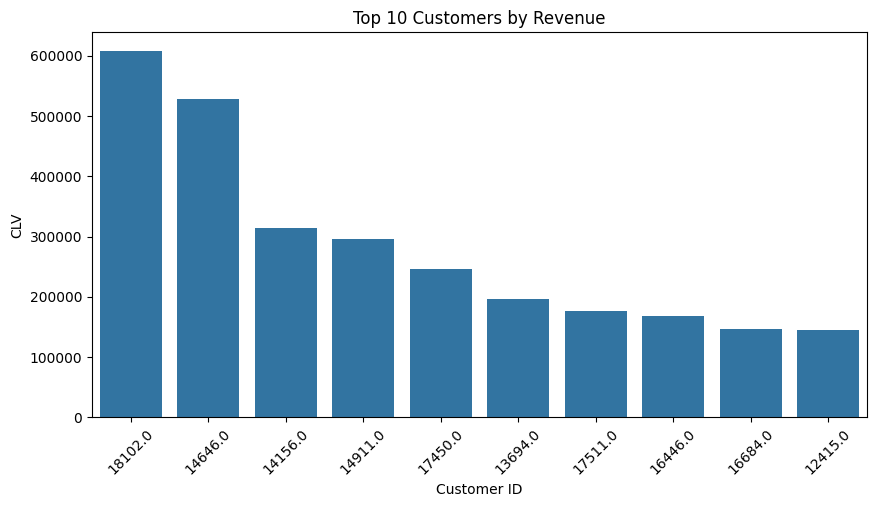

In [7]:
top_customers = clv.sort_values(
    "CLV",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_customers.index.astype(str),
    y=top_customers["CLV"]
)

plt.title("Top 10 Customers by Revenue")
plt.xticks(rotation=45)

plt.show()

In [8]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [9]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [10]:
monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales.head()

Month
2009-12    825685.760
2010-01    652708.502
2010-02    553713.306
2010-03    833570.131
2010-04    681528.992
Freq: M, Name: Sales, dtype: float64

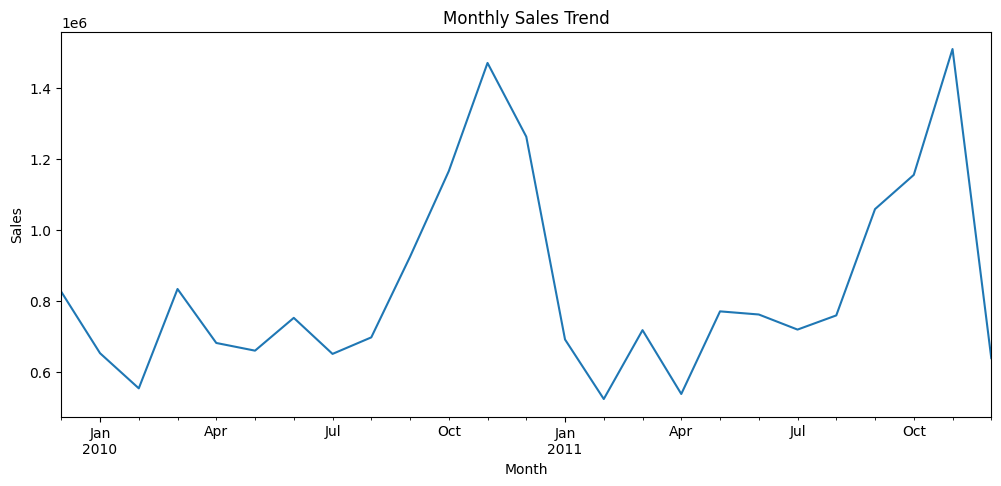

In [11]:
monthly_sales.plot(
    figsize=(12,5)
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [12]:
country_sales = df.groupby(
    "Country"
)["Sales"].sum().sort_values(
    ascending=False
)

country_sales.head(10)

Country
United Kingdom    1.787135e+07
EIRE              6.644318e+05
Netherlands       5.542323e+05
Germany           4.312625e+05
France            3.569446e+05
Australia         1.699681e+05
Spain             1.091785e+05
Switzerland       1.010113e+05
Sweden            9.190372e+04
Denmark           6.986219e+04
Name: Sales, dtype: float64

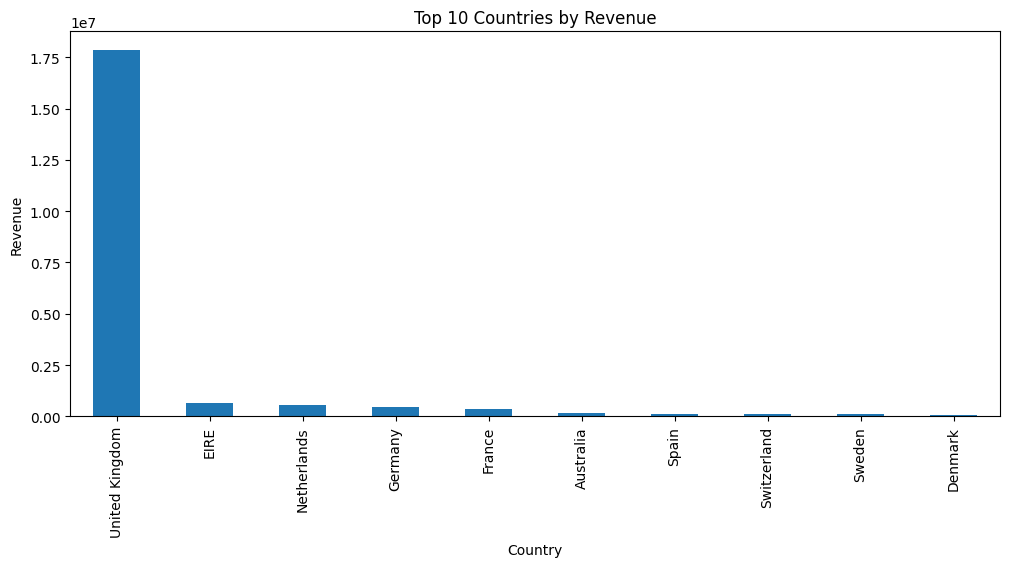

In [13]:
plt.figure(figsize=(12,5))

country_sales.head(10).plot(
    kind="bar"
)

plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")

plt.show()

In [14]:
product_sales = df.groupby(
    "Description"
)["Quantity"].sum().sort_values(
    ascending=False
)

product_sales.head(10)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     110138
WHITE HANGING HEART T-LIGHT HOLDER     96683
ASSORTED COLOUR BIRD ORNAMENT          81809
PAPER CRAFT , LITTLE BIRDIE            80995
JUMBO BAG RED RETROSPOT                79279
MEDIUM CERAMIC TOP STORAGE JAR         78033
BROCADE RING PURSE                     71430
PACK OF 60 PINK PAISLEY CAKE CASES     56794
60 TEATIME FAIRY CAKE CASES            54716
SMALL POPCORN HOLDER                   49948
Name: Quantity, dtype: int64

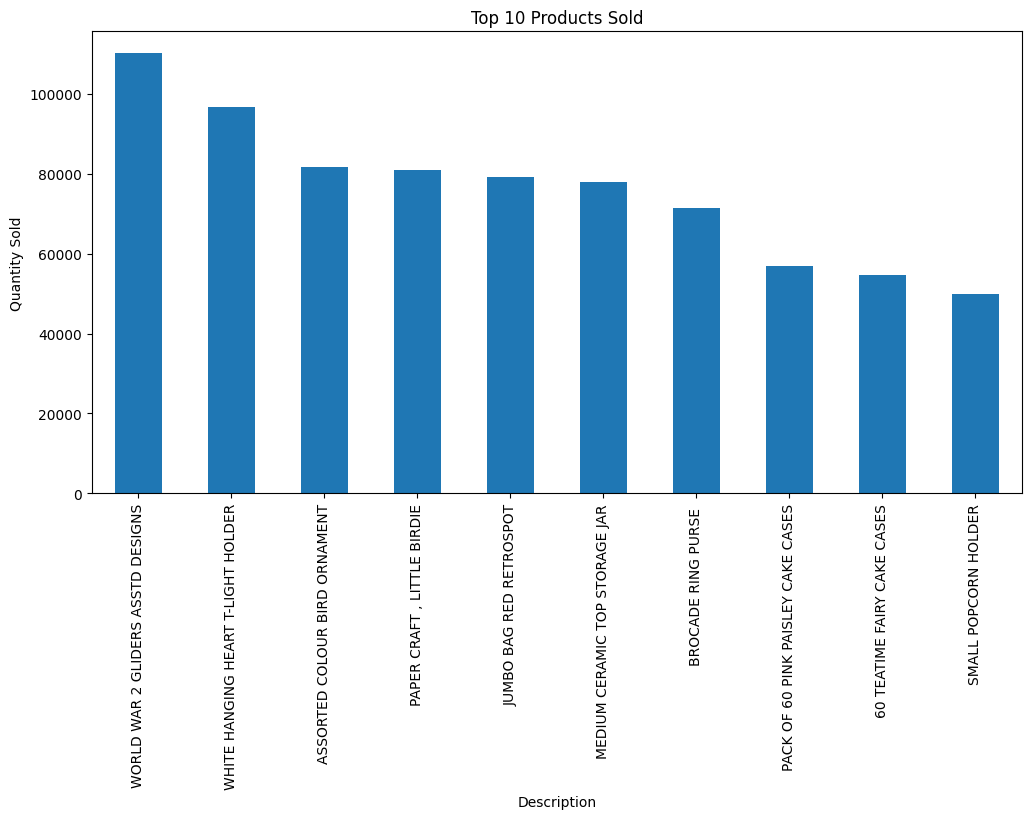

In [15]:
plt.figure(figsize=(12,6))

product_sales.head(10).plot(
    kind="bar"
)

plt.title("Top 10 Products Sold")
plt.ylabel("Quantity Sold")

plt.show()

In [16]:
clv.head()
clv.describe()

,Total_Revenue,Total_Orders,CLV
count,5878.000000,5878.000000,5878.000000
mean,3018.616737,6.290065,3018.616737
std,14737.731040,13.010973,14737.731040
min,2.950000,1.000000,2.950000
25%,348.762500,1.000000,348.762500
50%,898.915000,3.000000,898.915000
75%,2307.090000,7.000000,2307.090000
max,608821.650000,398.000000,608821.650000


In [17]:
top_customers = clv.sort_values(
    by="CLV",
    ascending=False
).head(10)

top_customers

,Total_Revenue,Total_Orders,CLV
Customer ID,,,
18102.0,608821.65,145,608821.65
14646.0,528602.52,151,528602.52
14156.0,313946.37,156,313946.37
14911.0,295972.63,398,295972.63
17450.0,246973.09,52,246973.09
13694.0,196482.81,143,196482.81
17511.0,175603.55,60,175603.55
16446.0,168472.50,2,168472.50
16684.0,147142.77,55,147142.77


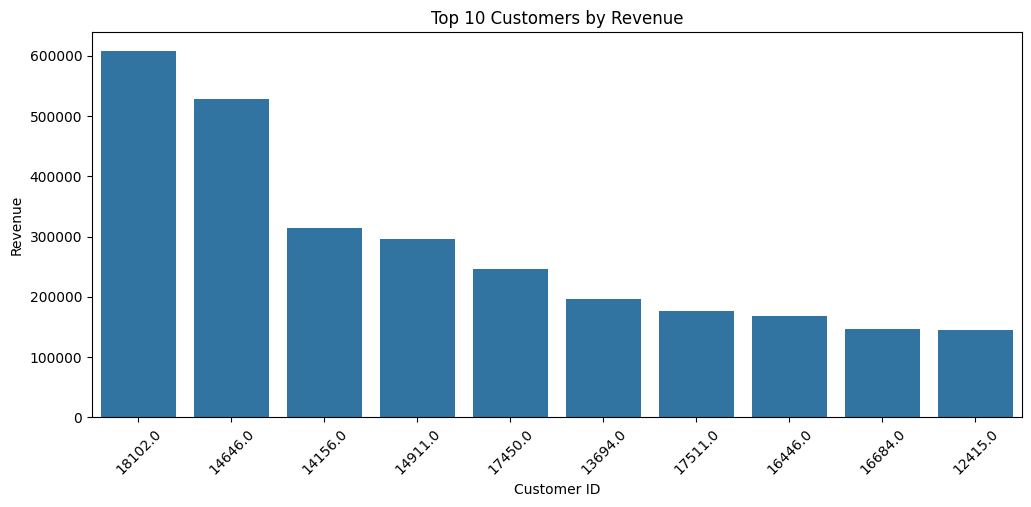

In [18]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=top_customers.index.astype(str),
    y=top_customers["CLV"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

In [19]:
monthly_sales.sort_values(
    ascending=False
).head(10)

Month
2011-11    1509496.330
2010-11    1470272.482
2010-12    1262598.790
2010-10    1165483.910
2011-10    1154979.300
2011-09    1058590.172
2010-09     924333.011
2010-03     833570.131
2009-12     825685.760
2011-05     770536.020
Freq: M, Name: Sales, dtype: float64

In [20]:
country_sales.head(10)

Country
United Kingdom    1.787135e+07
EIRE              6.644318e+05
Netherlands       5.542323e+05
Germany           4.312625e+05
France            3.569446e+05
Australia         1.699681e+05
Spain             1.091785e+05
Switzerland       1.010113e+05
Sweden            9.190372e+04
Denmark           6.986219e+04
Name: Sales, dtype: float64

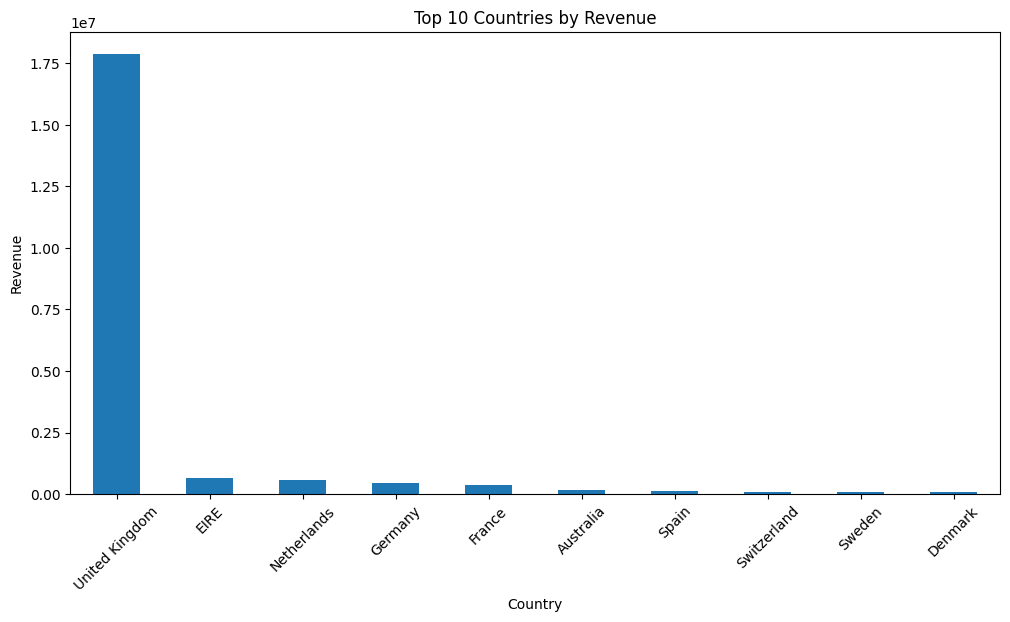

In [21]:
country_sales = (
    df.groupby("Country")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
country_sales.plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.xlabel("Country")
plt.xticks(rotation=45)

plt.show()

In [22]:
clv["CLV_Segment"] = pd.qcut(
    clv["CLV"],
    q=4,
    labels=["Low Value", "Medium Value", "High Value", "VIP"]
)

clv["CLV_Segment"].value_counts()

CLV_Segment
Low Value       1470
VIP             1470
Medium Value    1469
High Value      1469
Name: count, dtype: int64

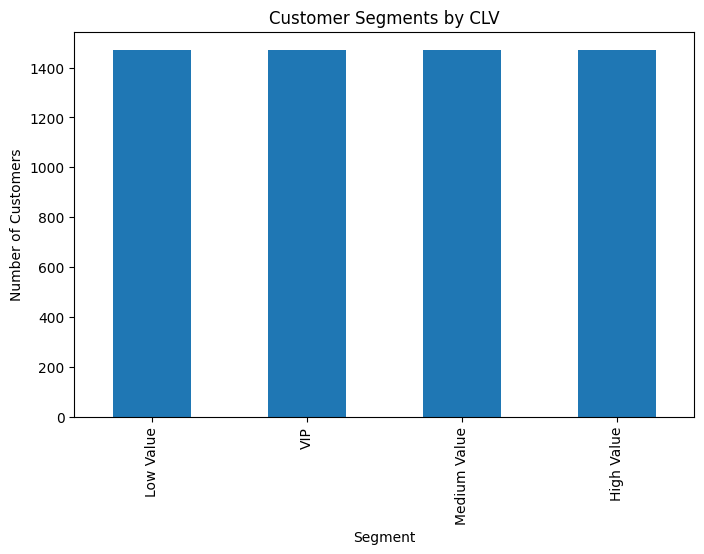

In [23]:
plt.figure(figsize=(8,5))

clv["CLV_Segment"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Segments by CLV")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

In [24]:
# Save CLV dataset
clv.to_csv("../data/processed/customer_clv.csv")

print("CLV dataset saved!")

CLV dataset saved!


In [25]:
clv.head()

,Total_Revenue,Total_Orders,CLV,CLV_Segment
Customer ID,,,,
12346.0,77556.46,12,77556.46,VIP
12347.0,5633.32,8,5633.32,VIP
12348.0,2019.40,5,2019.40,High Value
12349.0,4428.69,4,4428.69,VIP
12350.0,334.40,1,334.40,Low Value
